# Bank Customer Churn (AI Automated & ML Integrated) Analysis

## Business Problem

A Bank's leadership has identified an overall customer churn rate of 
20.37% through routine reporting and is concerned about its impact on 
revenue, given that acquiring a new customer costs significantly more than 
retaining an existing one. However, the underlying drivers of this churn 
and the specific customer segments most at risk remain unclear. The 
analytics team has been asked to investigate WHY customers are leaving and 
WHERE retention efforts should be prioritized.

## Key Business Questions

1. **Segment risk**: Which customer segments — by geography, age, gender, 
   activity status, and number of products held — show the highest churn risk?
2. **Compound risk**: Do these risk factors interact (e.g., does being both 
   female and German compound churn risk beyond either factor alone)?
3. **Statistical validity**: Are the differences observed across segments 
   statistically significant, or could they be explained by random variation?
4. **Financial behavior**: Does account balance, credit score, or tenure 
   relate meaningfully to churn?
5. **Predictive modeling**: Can we build a model to flag at-risk customers 
   in advance, and which factors matter most in that prediction?
6. **Business narrative**: Can we generate clear, automated, business-ready 
   insights and recommendations from this analysis without manual reporting 
   each time and also build an interactive dashboard for client presentations?

## Success Criteria

A churn prediction model with meaningfully better precision/recall on the 
"churned" class than random targeting, statistically validated segment-level 
findings, and clear, automatically generated retention recommendations the 
business can act on.

In [3]:
import os
print(os.path.exists(".env"))

False


In [4]:
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine
import os

load_dotenv("../.env")

engine = create_engine(
    f'postgresql://{os.getenv("DB_USER")}:{os.getenv("DB_PASS")}@{os.getenv("DB_HOST")}:{os.getenv("DB_PORT")}/{os.getenv("DB_NAME")}'
)

df = pd.read_sql("SELECT * FROM customers_bank", engine)
print("Setup complete — all libraries loaded, database connected, data loaded.")
df.head()

Setup complete — all libraries loaded, database connected, data loaded.


,row_number,customer_id,surname,credit_score,geography,gender,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,True,True,101348.88,True
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,False,True,112542.58,False
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,True,False,113931.57,True
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,False,False,93826.63,False
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,True,True,79084.10,False


### 1. SQL Exploratory Analysis

Quick aggregate queries run directly against the PostgreSQL database using 
window functions, CTEs, subquery and conditional logic to answer common business 
questions before deeper analysis in Python.

### 1.1 CTE: Churn Rate by Geography

In [5]:
query1 = """
WITH churn_summary AS (
    SELECT geography, COUNT(*) as total_customers,
           SUM(CASE WHEN exited THEN 1 ELSE 0 END) as churned_customers
    FROM customers_bank GROUP BY geography
)
SELECT geography, total_customers, churned_customers,
       ROUND(100.0 * churned_customers / total_customers, 2) as churn_rate_pct
FROM churn_summary ORDER BY churn_rate_pct DESC;
"""
result1 = pd.read_sql(query1, engine)
result1

,geography,total_customers,churned_customers,churn_rate_pct
0,Germany,2509,814,32.44
1,Spain,2477,413,16.67
2,France,5014,810,16.15


**Finding**: CTE confirms Germany's churn rate (32.44%) is roughly double 
France (16.15%) and Spain (16.67%), calculated directly in SQL — matches 
Python analysis, validating consistency across both approaches.

### 1.2 Window Function + Subquery: Top Balances by Geography

In [6]:
query2 = """
SELECT customer_id, geography, balance, balance_rank
FROM (
    SELECT customer_id, geography, balance,
           RANK() OVER (PARTITION BY geography ORDER BY balance DESC) as balance_rank
    FROM customers_bank
) ranked
WHERE balance_rank <= 5
ORDER BY geography, balance_rank;
"""
result2 = pd.read_sql(query2, engine)
result2

,customer_id,geography,balance,balance_rank
0,15715622,France,238387.56,1
1,15769818,France,212778.20,2
2,15780212,France,212692.97,3
3,15690589,France,212314.03,4
4,15671256,France,211774.31,5
5,15599131,Germany,214346.96,1
6,15620268,Germany,212696.32,2
7,15795298,Germany,206868.78,3
8,15745433,Germany,205770.78,4
9,15663888,Germany,204017.40,5


**Finding**: Window function ranks top 5 highest-balance customers within 
each country. Spain's top customer holds the highest single balance overall 
(250,898.09) despite Spain having the smallest customer base — an outlier 
worth noting separately from the aggregate churn analysis.

### 1.3 CASE WHEN: Customer Risk Tier Segmentation

In [7]:
query3 = """
SELECT 
    CASE 
        WHEN age BETWEEN 51 AND 60 AND num_of_products >= 3 THEN 'Critical Risk'
        WHEN age BETWEEN 51 AND 60 OR num_of_products >= 3 THEN 'High Risk'
        WHEN is_active_member = false THEN 'Moderate Risk'
        ELSE 'Low Risk'
    END as risk_tier,
    COUNT(*) as customer_count,
    ROUND(100.0 * SUM(CASE WHEN exited THEN 1 ELSE 0 END) / COUNT(*), 2) as churn_rate_pct
FROM customers_bank
GROUP BY risk_tier
ORDER BY churn_rate_pct DESC;
"""
result3 = pd.read_sql(query3, engine)
result3

,risk_tier,customer_count,churn_rate_pct
0,Critical Risk,60,98.33
1,High Risk,1003,60.82
2,Moderate Risk,4364,20.23
3,Low Risk,4573,10.61


**Finding**: Combining age (51-60) and product count (3+) into a risk-tier 
segmentation reveals a clear, actionable gradient — Critical Risk customers 
(60 people, 98.33% churn) and High Risk customers (1,003 people, 60.82% 
churn) represent priority targets for immediate retention intervention. This 
single query could directly drive a retention campaign target list.

In [8]:
from sqlalchemy import text

create_lookup = """
CREATE TABLE IF NOT EXISTS geography_risk_profile (
    geography VARCHAR(50) PRIMARY KEY,
    market_type VARCHAR(50),
    retention_budget_tier VARCHAR(50)
);

INSERT INTO geography_risk_profile (geography, market_type, retention_budget_tier)
VALUES 
    ('Germany', 'High-Risk Market', 'Priority Budget'),
    ('France', 'Stable Market', 'Standard Budget'),
    ('Spain', 'Stable Market', 'Standard Budget')
ON CONFLICT (geography) DO NOTHING;
"""

with engine.connect() as conn:
    conn.execute(text(create_lookup))
    conn.commit()

print("Lookup table created successfully")

Lookup table created successfully


### 1.4 JOIN: Churned Customer Value by Market Risk Profile

In [9]:
query4 = """
SELECT g.market_type, g.retention_budget_tier,
       COUNT(c.customer_id) as churned_customers,
       ROUND(AVG(c.balance), 2) as avg_churned_balance,
       ROUND(SUM(c.balance), 2) as total_churned_balance
FROM customers_bank c
JOIN geography_risk_profile g ON c.geography = g.geography
WHERE c.exited = true
GROUP BY g.market_type, g.retention_budget_tier
ORDER BY total_churned_balance DESC;
"""
result4 = pd.read_sql(query4, engine)
result4

,market_type,retention_budget_tier,churned_customers,avg_churned_balance,total_churned_balance
0,High-Risk Market,Priority Budget,814,120361.08,97973915.53
1,Stable Market,Standard Budget,1223,71638.74,87614179.10


**Finding**: JOIN with market classification reveals Germany's churned 
customers carry a 68% higher average balance ($120,361 vs $71,638 dollars) than 
those in stable markets. Despite having fewer churned customers than France 
and Spain combined, Germany's high-risk market segment accounts for nearly 
$98M in lost customer value — confirming Germany warrants disproportionate 
retention budget priority, not just attention.

# 2. Exploratory Data Analysis (EDA)

In [8]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   row_number        10000 non-null  int64  
 1   customer_id       10000 non-null  int64  
 2   surname           10000 non-null  str    
 3   credit_score      10000 non-null  int64  
 4   geography         10000 non-null  str    
 5   gender            10000 non-null  str    
 6   age               10000 non-null  int64  
 7   tenure            10000 non-null  int64  
 8   balance           10000 non-null  float64
 9   num_of_products   10000 non-null  int64  
 10  has_cr_card       10000 non-null  bool   
 11  is_active_member  10000 non-null  bool   
 12  estimated_salary  10000 non-null  float64
 13  exited            10000 non-null  bool   
dtypes: bool(3), float64(2), int64(6), str(3)
memory usage: 1.0 MB


row_number          0
customer_id         0
surname             0
credit_score        0
geography           0
gender              0
age                 0
tenure              0
balance             0
num_of_products     0
has_cr_card         0
is_active_member    0
estimated_salary    0
exited              0
dtype: int64

### Data Modelling (Adding new columns for better analysis)

In [9]:
# Balance-to-Salary ratio — financial health indicator
df['balance_salary_ratio'] = df['balance'] / df['estimated_salary']

# Age groups — bucketing for segment analysis
df['age_group'] = pd.cut(df['age'], bins=[18,30,40,50,60,100], 
                           labels=['18-30','31-40','41-50','51-60','60+'])

# Tenure groups
df['tenure_group'] = pd.cut(df['tenure'], bins=[-1,2,5,8,10], 
                              labels=['New(0-2)','Growing(3-5)','Established(6-8)','Loyal(9-10)'])

# Products per tenure year — engagement depth
df['products_per_tenure'] = df['num_of_products'] / (df['tenure'] + 1)  # +1 avoids div/0

# Is high value customer (balance + salary combined threshold)
df['high_value_customer'] = ((df['balance'] > df['balance'].median()) & 
                               (df['estimated_salary'] > df['estimated_salary'].median())).astype(int)

# Zero balance flag — many banks track this as risk signal
df['zero_balance_flag'] = (df['balance'] == 0).astype(int)

# Engagement score — composite from HasCrCard + IsActiveMember + NumOfProducts
df['engagement_score'] = df['has_cr_card'].astype(int) + df['is_active_member'].astype(int) + df['num_of_products']

In [10]:
df.head()

,row_number,customer_id,surname,credit_score,geography,gender,age,tenure,balance,num_of_products,...,is_active_member,estimated_salary,exited,balance_salary_ratio,age_group,tenure_group,products_per_tenure,high_value_customer,zero_balance_flag,engagement_score
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,...,True,101348.88,True,0.000000,41-50,New(0-2),0.333333,0,1,3
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,...,True,112542.58,False,0.744677,41-50,New(0-2),0.500000,0,0,2
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,...,False,113931.57,True,1.401375,41-50,Established(6-8),0.333333,1,0,4
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,...,False,93826.63,False,0.000000,31-40,New(0-2),1.000000,0,1,2
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,...,True,79084.10,False,1.587055,41-50,New(0-2),0.333333,0,0,3


### 2.1 Overall Churn Rate

In [11]:
churn_rate = df['exited'].mean() * 100
print(f"Overall churn rate: {churn_rate:.2f}%")

Overall churn rate: 20.37%


**Finding**: Overall churn rate is 20.37% — roughly 1 in 5 customers left, 
a significant revenue risk requiring investigation.

### 2.2 Churn Distribution 

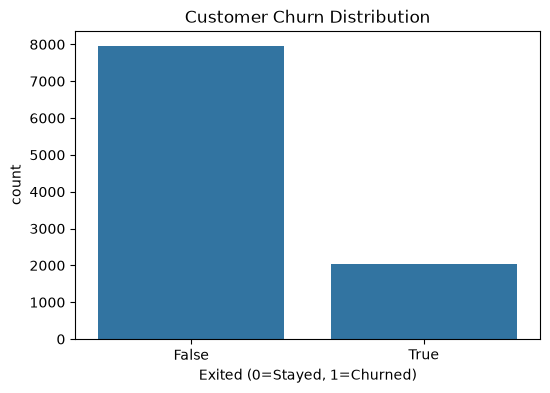

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='exited')
plt.title('Customer Churn Distribution')
plt.xlabel('Exited (0=Stayed, 1=Churned)')
plt.show()

### 2.3 Churn by Geography 

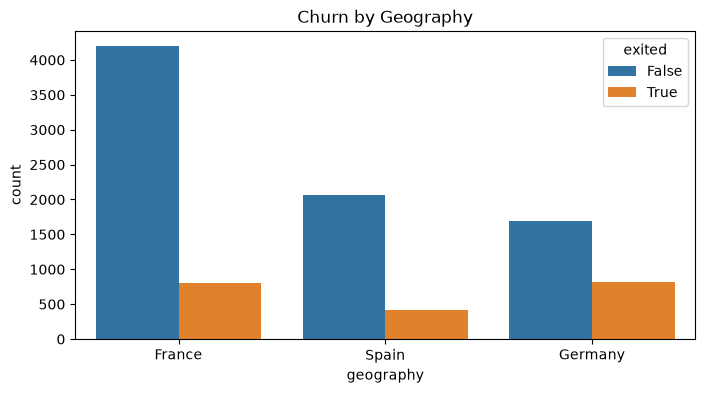

In [13]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='geography', hue='exited')
plt.title('Churn by Geography')
plt.show()

In [14]:
df.groupby('geography')['exited'].mean() * 100

geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: exited, dtype: float64

**Finding**: Germany shows 32.44% churn vs France (16.15%) and Spain (16.67%) 
— nearly double, despite having fewer total customers than France.

### 2.4 Churn by Gender

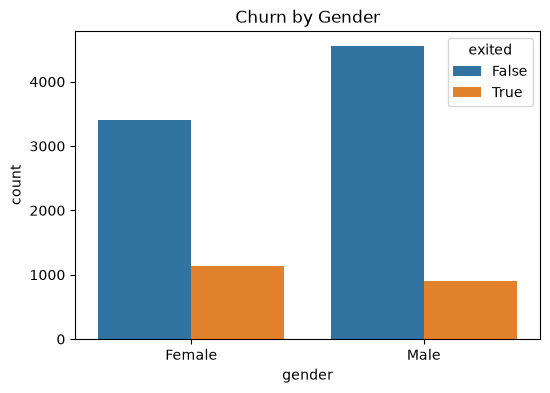

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='gender', hue='exited')
plt.title('Churn by Gender')
plt.show()

In [16]:
df.groupby('gender')['exited'].mean() * 100

gender
Female    25.071539
Male      16.455928
Name: exited, dtype: float64

**Finding**: Female customers churn at 25.07% vs Male at 16.46% — a notable 
8.6 percentage point gap.

### 2.5 Churn by Age Group

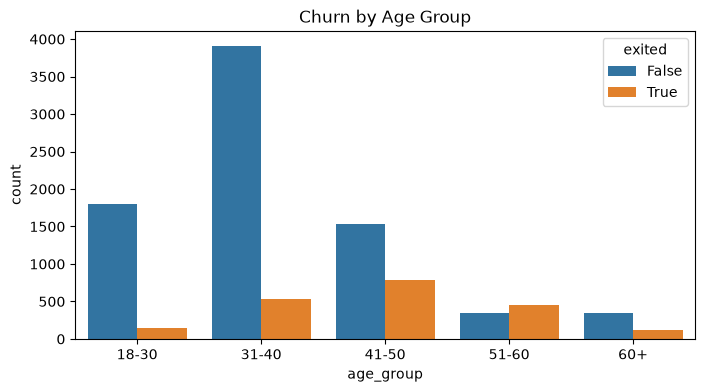

In [17]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='age_group', hue='exited')
plt.title('Churn by Age Group')
plt.show()

In [18]:
df.groupby('age_group')['exited'].mean() * 100

age_group
18-30     7.502569
31-40    12.087171
41-50    33.965517
51-60    56.210790
60+      24.784483
Name: exited, dtype: float64

**Finding**: Churn rises sharply with age, peaking at 51-60 (56.21%) — an 
inverted-U pattern, not linear. This age band is the highest-priority 
retention target.

### 2.6 Churn by Active Membership

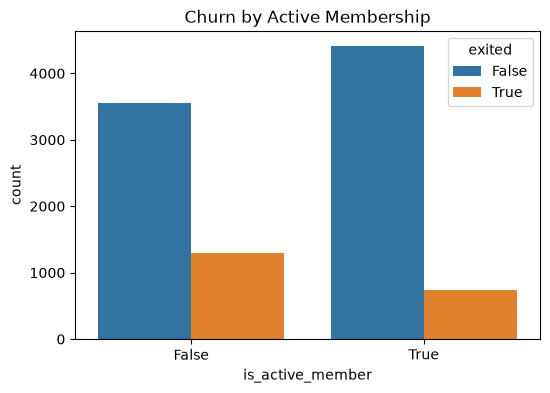

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='is_active_member', hue='exited')
plt.title('Churn by Active Membership')
plt.show()

In [20]:
df.groupby('is_active_member')['exited'].mean() * 100

is_active_member
False    26.850897
True     14.269074
Name: exited, dtype: float64

**Finding**: Inactive members churn at 26.85% vs active members at 14.27% 
— engagement is a strong protective factor.

### 2.7 Churn by Number of Products

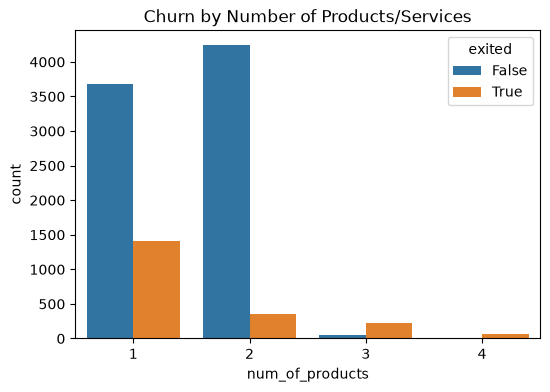

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='num_of_products', hue='exited')
plt.title('Churn by Number of Products/Services')
plt.show()

In [22]:
df.groupby('num_of_products')['exited'].mean() * 100

num_of_products
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: exited, dtype: float64

In [23]:
df['num_of_products'].value_counts()

num_of_products
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

**Finding**: Non-linear, counter-intuitive pattern — 2 products = lowest 
churn (7.58%), but 3-4 products spike to 82-100% churn. Note: 4-product 
segment is small (n=60), so treat with caution, but the pattern strongly 
suggests over-selling/product mismatch rather than genuine loyalty.

### 2.8 Correlation Heatmap

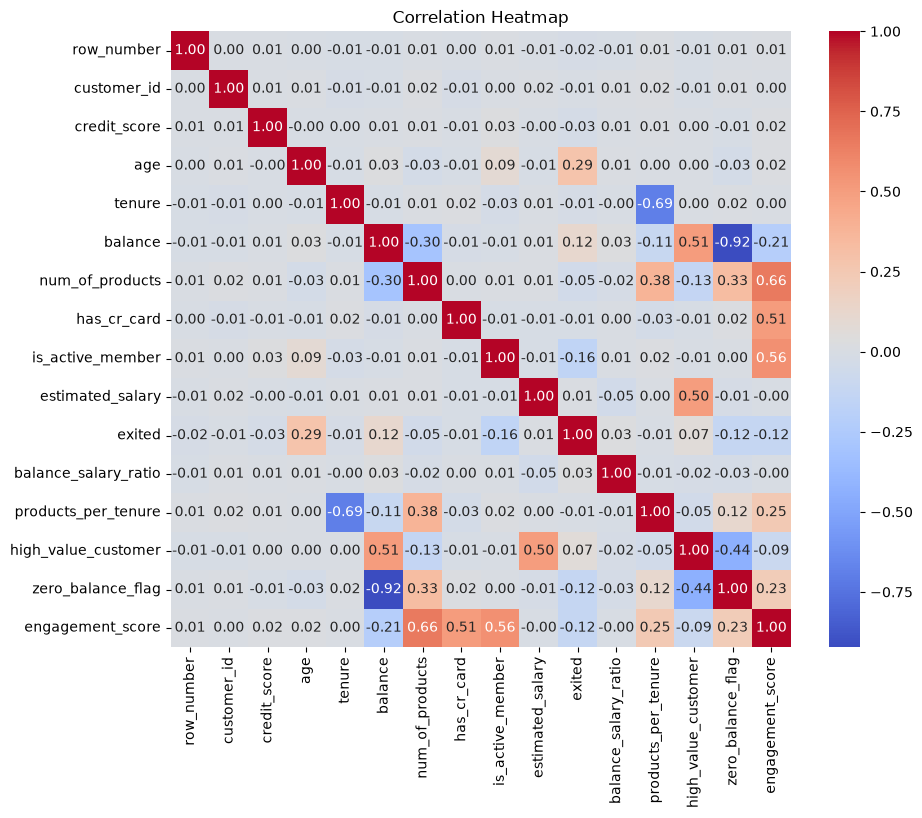

In [24]:
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=['int64','float64','bool'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**Finding**: Age (0.29) is the strongest linear correlate with churn. 
Num_of_products shows weak linear correlation (-0.05) despite being a strong 
predictor in EDA — confirms the relationship is non-linear, not captured by 
Pearson correlation. Multicollinearity flagged between balance/zero_balance_flag 
(-0.92) and tenure/products_per_tenure (-0.69) — will need to address before ML.

### 2.9 Churn by Credit Score Band

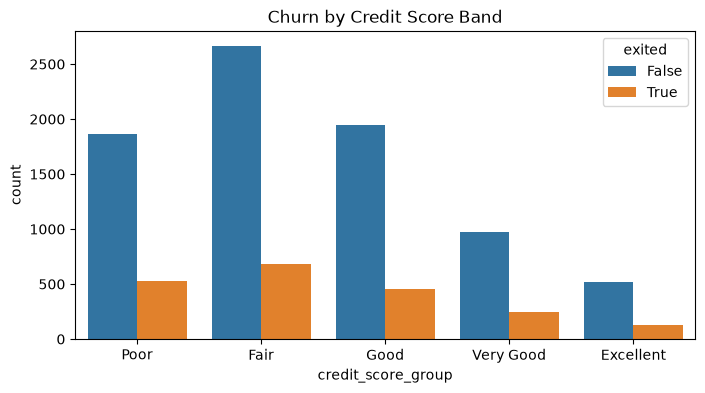

In [25]:
df['credit_score_group'] = pd.cut(df['credit_score'], bins=[300,580,670,740,800,850],
                                    labels=['Poor','Fair','Good','Very Good','Excellent'])

plt.figure(figsize=(8,4))
sns.countplot(data=df, x='credit_score_group', hue='exited')
plt.title('Churn by Credit Score Band')
plt.show()

In [26]:
df.groupby('credit_score_group')['exited'].mean() * 100

credit_score_group
Poor         22.147931
Fair         20.388060
Good         18.815186
Very Good    20.246914
Excellent    19.689922
Name: exited, dtype: float64

**Finding**: No meaningful pattern (19-22% flat across all credit bands) — 
churn appears behavioral/relational rather than financial-risk-driven.

### 2.10 Balance Distribution: Churned vs Stayed

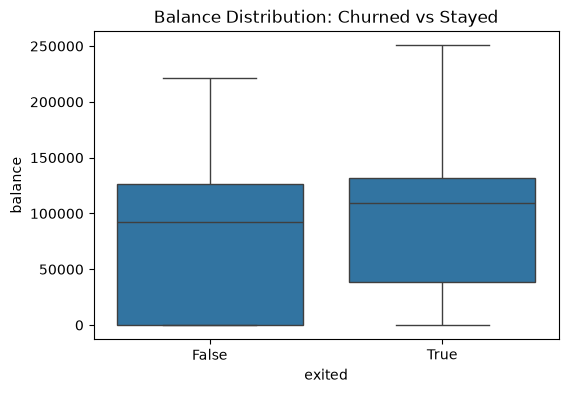

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='exited', y='balance')
plt.title('Balance Distribution: Churned vs Stayed')
plt.show()

**Finding**: Churned customers have slightly HIGHER median balance (~108K) 
than stayed customers (~92K) — counter-intuitive; suggests high-value customers 
may be under-served or targeted by competitors, not just "safe" by default.

### 2.11 Age Distribution: Churned vs Stayed

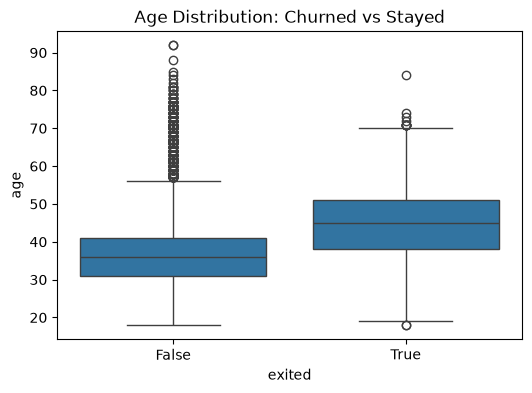

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='exited', y='age')
plt.title('Age Distribution: Churned vs Stayed')
plt.show()

**Finding**: Clear separation — churned median age ~45 vs stayed ~36, 
confirming age as a top predictor.

### 2.12 Churn Rate by Geography and Gender

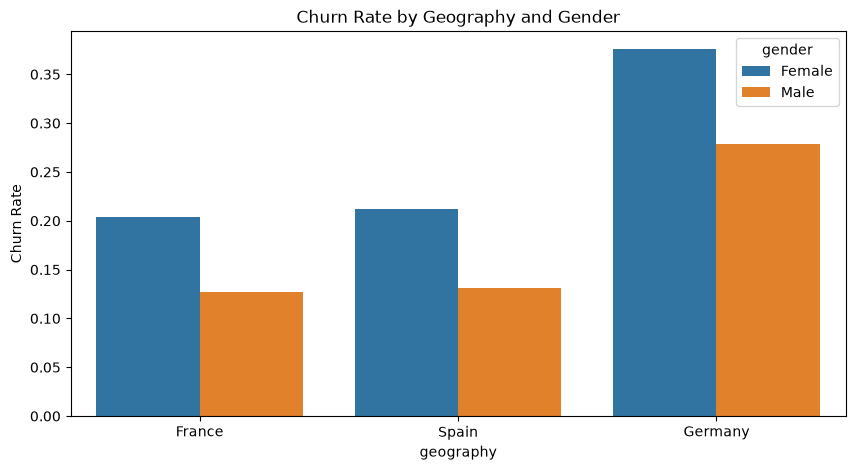

In [29]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x='geography', y='exited', hue='gender', errorbar=None)
plt.title('Churn Rate by Geography and Gender')
plt.ylabel('Churn Rate')
plt.show()

**Finding**: Risk factors compound - German female customers face ~37% churn, 
the highest combined-risk segment identified in this analysis.

### 2.13 Churn Rate by Geography and Age Group

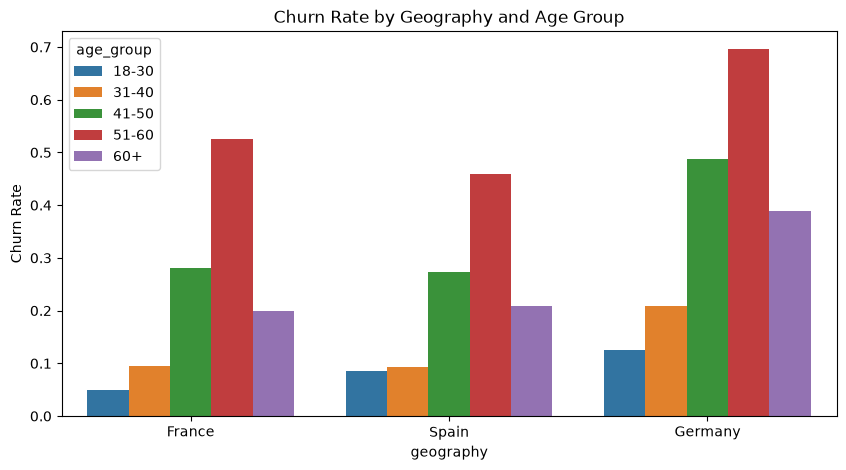

In [30]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x='geography', y='exited', hue='age_group', errorbar=None)
plt.title('Churn Rate by Geography and Age Group')
plt.ylabel('Churn Rate')
plt.show()

**Finding**: Same age-driven churn curve appears in all three countries, but 
Germany amplifies every age bracket by roughly 15-20 percentage points — 
suggests a systemic, market-wide issue in Germany rather than a 
demographic-specific one.

### 2.14 Churn Rate Trend by Tenure

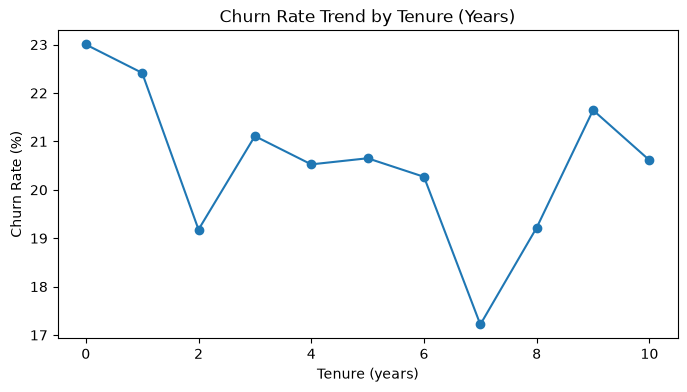

In [31]:
plt.figure(figsize=(8,4))
tenure_churn = df.groupby('tenure')['exited'].mean() * 100
tenure_churn.plot(kind='line', marker='o')
plt.title('Churn Rate Trend by Tenure (Years)')
plt.xlabel('Tenure (years)')
plt.ylabel('Churn Rate (%)')
plt.show()

**Finding**: No meaningful trend — churn stays flat (17-23%) regardless of 
tenure. Loyalty does not appear to build naturally over time.

### 2.15 Age Distribution Shape (Violin Plot)

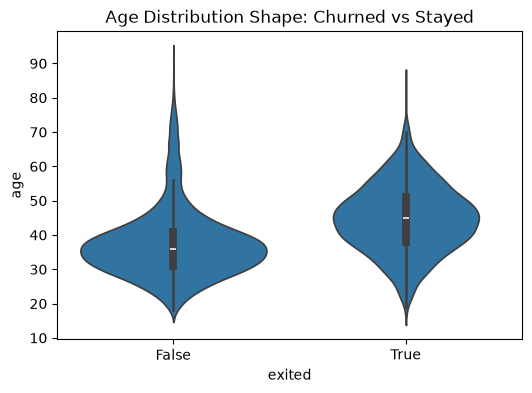

In [32]:
plt.figure(figsize=(6,4))
sns.violinplot(data=df, x='exited', y='age')
plt.title('Age Distribution Shape: Churned vs Stayed')
plt.show()

**Finding**: Confirms age boxplot with more detail — stayed customers are 
tightly concentrated in a younger band with a long thin tail; churned 
customers are more evenly spread across a higher age range.

# 3. Statistical Hypothesis Testing

### 3.1 Chi-Square Test: Geography vs Churn

In [33]:
from scipy.stats import chi2_contingency

contingency_geo = pd.crosstab(df['geography'], df['exited'])
chi2, p_value, dof, expected = chi2_contingency(contingency_geo)
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")
print("Significant" if p_value < 0.05 else "Not Significant")

Chi-Square Statistic: 301.2553
P-value: 0.000000
Significant


**Finding**: Chi-Square test confirms geography's effect on churn is 
statistically significant (χ² = 301.26, p < 0.001) — Germany's higher churn 
rate is a real, non-random pattern, not sampling variation. Safe to treat as 
a genuine business signal.

### 3.2 Chi-Square Test: Gender vs Churn

In [34]:
contingency_gender = pd.crosstab(df['gender'], df['exited'])
chi2, p_value, dof, expected = chi2_contingency(contingency_gender)
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")
print("Significant" if p_value < 0.05 else "Not Significant")

Chi-Square Statistic: 112.9186
P-value: 0.000000
Significant


**Finding**: Chi-Square test confirms gender's effect on churn is 
statistically significant (χ² = 112.92, p < 0.001) — the gap between Female 
(25.07%) and Male (16.46%) churn rates is a real pattern, not random 
variation.

### 3.3 T-Test: Age (Churned vs Stayed)

In [35]:
from scipy.stats import ttest_ind

churned_age = df[df['exited']==True]['age']
stayed_age = df[df['exited']==False]['age']
t_stat, p_value = ttest_ind(churned_age, stayed_age)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print("Significant" if p_value < 0.05 else "Not Significant")

T-statistic: 29.7668
P-value: 0.000000
Significant


**Finding**: T-test confirms the age difference between churned (~45) and 
stayed (~36) customers is statistically significant (t = 29.77, p < 0.001) 
— validates age as one of the strongest, most reliable churn predictors.

### 3.4 T-Test: Balance (Churned vs Stayed)

In [36]:
churned_balance = df[df['exited']==True]['balance']
stayed_balance = df[df['exited']==False]['balance']
t_stat, p_value = ttest_ind(churned_balance, stayed_balance)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print("Significant" if p_value < 0.05 else "Not Significant")

T-statistic: 11.9362
P-value: 0.000000
Significant


**Finding**: T-test confirms the balance difference between churned 
(~108K median) and stayed (~92K median) customers is statistically 
significant (t = 11.94, p < 0.001) — validates the counter-intuitive finding 
that higher-balance customers are more likely to churn, not less.

# 4. Machine Learning Model Building

## 4.1 Data Preparation

### 4.1.1 Drop Redundant and Non-Predictive Columns

In [37]:
df_model = df.drop(columns=[
    'row_number', 'customer_id', 'surname',  # identifiers, no predictive value
    'zero_balance_flag',  # redundant with balance (-0.92 correlation)
    'products_per_tenure',  # redundant with tenure (-0.69 correlation)
    'age_group', 'tenure_group', 'credit_score_group'  # binned versions, raw columns already capture this
])
df_model.head()

,credit_score,geography,gender,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,exited,balance_salary_ratio,high_value_customer,engagement_score
0,619,France,Female,42,2,0.00,1,True,True,101348.88,True,0.000000,0,3
1,608,Spain,Female,41,1,83807.86,1,False,True,112542.58,False,0.744677,0,2
2,502,France,Female,42,8,159660.80,3,True,False,113931.57,True,1.401375,1,4
3,699,France,Female,39,1,0.00,2,False,False,93826.63,False,0.000000,0,2
4,850,Spain,Female,43,2,125510.82,1,True,True,79084.10,False,1.587055,0,3


**Note**: Dropped identifier columns (row_number, customer_id, surname) with 
no predictive value, and redundant engineered features (zero_balance_flag, 
products_per_tenure) flagged as multicollinear with balance and tenure in 
the correlation heatmap. Binned categorical versions (age_group, tenure_group, 
credit_score_group) dropped in favor of their raw numeric columns, which 
preserve more information for the model.

### 4.1.2 Encode Categorical Variables

In [38]:
df_model = pd.get_dummies(df_model, columns=['geography', 'gender'], drop_first=True)
df_model.head()

,credit_score,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,exited,balance_salary_ratio,high_value_customer,engagement_score,geography_Germany,geography_Spain,gender_Male
0,619,42,2,0.00,1,True,True,101348.88,True,0.000000,0,3,False,False,False
1,608,41,1,83807.86,1,False,True,112542.58,False,0.744677,0,2,False,True,False
2,502,42,8,159660.80,3,True,False,113931.57,True,1.401375,1,4,False,False,False
3,699,39,1,0.00,2,False,False,93826.63,False,0.000000,0,2,False,False,False
4,850,43,2,125510.82,1,True,True,79084.10,False,1.587055,0,3,False,True,False


**Note**: Geography and Gender converted to numeric binary columns via 
one-hot encoding (drop_first=True to avoid redundancy), since ML models 
require numeric input.

In [39]:
df_model.columns.tolist()

['credit_score',
 'age',
 'tenure',
 'balance',
 'num_of_products',
 'has_cr_card',
 'is_active_member',
 'estimated_salary',
 'exited',
 'balance_salary_ratio',
 'high_value_customer',
 'engagement_score',
 'geography_Germany',
 'geography_Spain',
 'gender_Male']

### 4.2 Train-Test Split

In [40]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['exited'])
y = df_model['exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (8000, 14)
Test set: (2000, 14)


**Note**: Data split into 80% training (8000 rows) and 20% testing (2000 rows), 
stratified to preserve the original 20.37% churn ratio in both sets — ensures 
fair model evaluation on unseen data.

### 4.3 Feature Scaling

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete")

Scaling complete


### 4.4 Model 1: Logistic Regression

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression Results")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_log):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_log):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_log):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Results
Accuracy: 0.8060
Precision: 0.5704
Recall: 0.1892
F1 Score: 0.2841

Confusion Matrix:
[[1535   58]
 [ 330   77]]

Classification Report:
              precision    recall  f1-score   support

       False       0.82      0.96      0.89      1593
        True       0.57      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.70      0.58      0.59      2000
weighted avg       0.77      0.81      0.76      2000



**Finding**: Logistic Regression achieves 80.6% accuracy but only 18.9% 
recall on the churned class — the model fails to identify most actual 
churners, likely because it cannot capture the non-linear patterns identified 
in EDA (e.g., the num_of_products spike at 3-4 products, the inverted-U age 
relationship). This motivates testing tree-based models (Random Forest), 
which handle non-linear relationships natively.

### 4.5 Model 2: Decision Tree

In [43]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Results")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_dt):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Results
Accuracy: 0.7860
Precision: 0.4754
Recall: 0.4988
F1 Score: 0.4868

Confusion Matrix:
[[1369  224]
 [ 204  203]]

Classification Report:
              precision    recall  f1-score   support

       False       0.87      0.86      0.86      1593
        True       0.48      0.50      0.49       407

    accuracy                           0.79      2000
   macro avg       0.67      0.68      0.68      2000
weighted avg       0.79      0.79      0.79      2000



**Finding**: A single Decision Tree achieves the highest raw recall (49.88%) 
among all models tested, but at the cost of significantly more false 
positives (224 vs Random Forest's 49) and lower overall accuracy (78.60%). 
This illustrates classic overfitting — a single tree captures more 
individual patterns (including noise) from training data, while Random 
Forest's averaging across 100 trees produces more stable, generalizable 
predictions.

### 4.6 Model 3: K-Nearest Neighbors (KNN)

In [44]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)  # KNN needs SCALED data (distance-based)

y_pred_knn = knn_model.predict(X_test_scaled)

print("KNN Results")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_knn):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Results
Accuracy: 0.8260
Precision: 0.6234
Recall: 0.3661
F1 Score: 0.4613

Confusion Matrix:
[[1503   90]
 [ 258  149]]

Classification Report:
              precision    recall  f1-score   support

       False       0.85      0.94      0.90      1593
        True       0.62      0.37      0.46       407

    accuracy                           0.83      2000
   macro avg       0.74      0.65      0.68      2000
weighted avg       0.81      0.83      0.81      2000



**Finding**: KNN (82.60% accuracy, 36.61% recall) outperforms Logistic 
Regression and single Decision Tree on overall balance (F1=0.46), but still 
falls well short of ensemble methods. This reinforces that tree-based 
ensembles (Random Forest, XGBoost) are best suited to this dataset's 
non-linear, interaction-heavy churn patterns — a single distance-based or 
linear model cannot capture the same complexity.

### 4.7 Model 4: Random Forest

In [45]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)  # Note: uses UNSCALED X_train, tree models don't need scaling

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_rf):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.8705
Precision: 0.8008
Recall: 0.4840
F1 Score: 0.6034

Confusion Matrix:
[[1544   49]
 [ 210  197]]

Classification Report:
              precision    recall  f1-score   support

       False       0.88      0.97      0.92      1593
        True       0.80      0.48      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



**Finding**: Random Forest dramatically outperforms Logistic Regression 
across all metrics — recall improves from 18.9% to 48.4% (catching 197 vs 77 
actual churners), confirming that churn patterns are largely non-linear and 
better captured by tree-based models. This validates the EDA finding that 
num_of_products and age relationships are non-linear, not well-suited to a 
linear model like Logistic Regression.

### 4.8 Model 5: XGBoost

In [46]:
pip install xgboost --break-system-packages

Note: you may need to restart the kernel to use updated packages.


In [47]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Results")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_xgb):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Results
Accuracy: 0.8570
Precision: 0.7153
Recall: 0.4939
F1 Score: 0.5843

Confusion Matrix:
[[1513   80]
 [ 206  201]]

Classification Report:
              precision    recall  f1-score   support

       False       0.88      0.95      0.91      1593
        True       0.72      0.49      0.58       407

    accuracy                           0.86      2000
   macro avg       0.80      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000



**Finding**: XGBoost (85.70% accuracy, 49.39% recall) performs comparably to 
Random Forest (87.05% accuracy, 48.40% recall), with a marginal recall 
improvement traded against lower precision. Given Random Forest's higher 
overall F1 score (60.34% vs 58.43%) and better precision (fewer false 
alarms), Random Forest is selected as the primary model — though both 
confirm tree-based ensembles substantially outperform linear approaches for 
this non-linear churn pattern.

### 4.9 Model Comparison Summary

In [48]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'KNN', 'Random Forest', 'XGBoost'],
    'Accuracy': [0.8060, 0.7860, 0.8260, 0.8705, 0.8570],
    'Precision': [0.5704, 0.4754, 0.6234, 0.8008, 0.7153],
    'Recall': [0.1892, 0.4988, 0.3661, 0.4840, 0.4939],
    'F1 Score': [0.2841, 0.4868, 0.4613, 0.6034, 0.5843]
}).sort_values('F1 Score', ascending=False)
comparison

,Model,Accuracy,Precision,Recall,F1 Score
3,Random Forest,0.8705,0.8008,0.4840,0.6034
4,XGBoost,0.8570,0.7153,0.4939,0.5843
1,Decision Tree,0.7860,0.4754,0.4988,0.4868
2,KNN,0.8260,0.6234,0.3661,0.4613
0,Logistic Regression,0.8060,0.5704,0.1892,0.2841


**Final Model Selection**: Random Forest selected as the best-performing 
model (F1=0.6034, highest among all 5 tested), offering the best balance of 
precision (80.08%) and recall (48.40%) for identifying at-risk customers 
while minimizing false alarms. XGBoost is a close second and could serve as 
an alternative if marginally higher recall is prioritized over precision.

### 4.10 Hyperparameter Tuning: Random Forest

In [49]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score (cross-validated):", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best F1 Score (cross-validated): 0.5783055059063994


In [50]:
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

print("Tuned Random Forest Results")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_best_rf):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_best_rf):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_rf))

Tuned Random Forest Results
Accuracy: 0.8640
Precision: 0.7824
Recall: 0.4595
F1 Score: 0.5789

Confusion Matrix:
[[1541   52]
 [ 220  187]]


**Finding**: Hyperparameter tuning via GridSearchCV (81 combinations, 5-fold 
cross-validation) identified best parameters (max_depth=None, 
min_samples_leaf=1, min_samples_split=5, n_estimators=100), achieving a 
cross-validated F1 of 0.578. However, when evaluated on the held-out test 
set, the tuned model (F1=0.579) performed marginally below the original 
default-parameter Random Forest (F1=0.603). This suggests the default 
configuration was already well-suited to this dataset, and the small 
performance difference falls within normal variance between train/test 
splits. The original Random Forest is retained as the final model.

### 4.11 Feature Importance (Final Model: Random Forest)

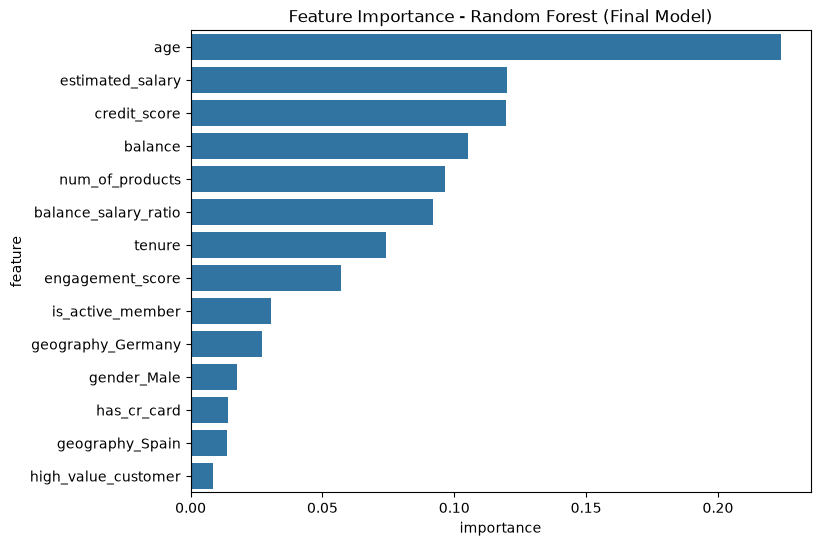

,feature,importance
1,age,0.223943
7,estimated_salary,0.120144
0,credit_score,0.119473
3,balance,0.105057
4,num_of_products,0.096384
8,balance_salary_ratio,0.092063
2,tenure,0.074239
10,engagement_score,0.056885
6,is_active_member,0.030457
11,geography_Germany,0.026998


In [51]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Feature Importance - Random Forest (Final Model)')
plt.show()

feature_importance

**Finding**: Feature importance confirms age as the dominant predictor 
(0.224), consistent with all earlier EDA and hypothesis testing. Notably, 
credit_score ranks 3rd (0.119) in the model despite appearing to have no 
relationship with churn in isolated EDA analysis (flat ~19-22% across credit 
bands) — this suggests credit_score interacts with other variables (e.g., 
age or balance) in ways that univariate analysis cannot detect, a key 
advantage of tree-based models over simple correlation or single-variable 
EDA. Geography, gender, and has_cr_card contribute comparatively little to 
the model's predictions, despite geography and gender showing strong 
standalone statistical significance — indicating their effect may be 
partially captured/absorbed by other correlated features like age and 
balance.

### 4.12 Save Trained Model

In [54]:
import joblib

joblib.dump(rf_model, '../models/random_forest_churn_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
print("Model saved successfully")

Model saved successfully


In [56]:
import os

print(os.path.exists('../models/random_forest_churn_model.pkl'))
print(os.path.exists('../models/scaler.pkl'))

True
True


In [2]:
from groq import Groq
print("Groq imported successfully")

Groq imported successfully


# 5. AI-Generated Business Report (Groq/Llama 3.3)

In [11]:
from groq import Groq

groq_client = Groq(api_key=os.getenv("GROQ_API_KEY"))

summary_stats = """
Overall churn rate: 20.37%
Churn by geography: Germany 32.44%, France 16.15%, Spain 16.67% (Chi-square p<0.001, significant)
Churn by gender: Female 25.07%, Male 16.46% (Chi-square p<0.001, significant)
Churn by age: rises sharply to 51-60 age group (56.21% peak), t-test p<0.001, significant
Compound risk: German female customers churn at ~37%, highest combined-risk segment
Churn by number of products: 1 product=27.71%, 2 products=7.58% (lowest), 3 products=82.71%, 4 products=100% (small sample, n=60)
Balance: churned customers have higher median balance ($108K vs $92K), t-test p<0.001, significant
Best ML model: Random Forest, Accuracy=87.05%, Precision=80.08%, Recall=48.40%, F1=0.6034
Top predictive features: age (22.4%), estimated_salary (12.0%), credit_score (11.9%), balance (10.5%), num_of_products (9.6%)
"""

prompt = f"""You are a data analyst writing a business report for bank leadership.
Based on the following validated statistical and machine learning findings, write a 
professional business report with: Executive Summary, Key Findings, and 
Actionable Recommendations. Keep it concise and business-focused, not overly technical.

Findings:
{summary_stats}
"""

response = groq_client.chat.completions.create(
    model="openai/gpt-oss-120b",
    messages=[{"role": "user", "content": prompt}]
)

report = response.choices[0].message.content
print(report)

**Bank‑Customer Churn Analysis – Business Report**  
*Prepared for Senior Leadership*  
*Date: September 2026*  

---

## 1. Executive Summary  

- **Overall churn** is **20.4 %** – one‑in‑five customers is leaving the bank each year.  
- **High‑risk segments** have been identified:  
  - **German female** customers (≈ 37 % churn) – the single most vulnerable cohort.  
  - **Customers age 51‑60** (56 % churn) and those holding **three or more products** (≥ 83 % churn).  
- **Financial impact:** churned customers hold a **higher median balance** ($108 K vs $92 K), indicating lost revenue potential.  
- A **Random‑Forest model** predicts churn with **87 % accuracy**; the strongest drivers are **age, estimated salary, credit score, balance, and product count**.  

These insights point to clear, profit‑driving opportunities: target retention resources where the revenue loss is greatest and where the likelihood of churn is highest.

---

## 2. Key Findings  

| Dimension | Churn Rate | Busi